# 🚢 Titanic: Why a Plausible Feature Can Make a Model Worse
## 仮説・失敗・再検証まで見せる Titanic 解説 Notebook

> **日本語** — この Notebook の主役は最高スコアではなく、再現できる思考プロセスです。
> **English** — The goal is not a magic score. It is a reproducible reasoning process.

**What you will learn / 学べること**

1. 生存率の差を、分母つきの可視化で読む / Read survival patterns with denominators.
2. 欠損処理を Pipeline の内側に置き、リークを防ぐ / Prevent leakage with pipelines.
3. `FamilySize` 仮説を「他条件を固定」して検証する / Test a feature hypothesis under controlled conditions.
4. 単一 holdout ではなく反復交差検証で不確実性を見る / Measure uncertainty with repeated CV.
5. 全体精度だけでなく、サブグループの失敗を見る / Inspect subgroup errors, not accuracy alone.
6. 投稿ファイルを検査してから保存する / Validate the submission before saving it.

**Navigation / 目次**
[Goal](#1-goal--目的) · [Setup](#2-setup--環境設定) · [Data](#3-data--データ) ·
[EDA](#4-eda--可視化) · [Modeling](#5-modeling--モデル) ·
[Error Analysis](#6-error-analysis--誤分類分析) · [Submission](#7-submission--提出) ·
[Takeaways](#8-takeaways--まとめ)

## 1. Goal / 目的

Kaggle Titanic は小さな表形式データですが、良い実験設計の練習に向いています。ここでは次の問いに答えます。

> **Does adding a plausible family feature improve out-of-sample accuracy?**
> もっともらしい家族特徴量を追加すると、未知データへの精度は改善するのか？

### Experiment contract / 実験条件

| Item | Decision |
|---|---|
| Target / 目的変数 | `Survived` (0 or 1) |
| Primary metric / 主指標 | Accuracy（Kaggle と同じ） |
| Secondary metrics / 補助指標 | ROC AUC, F1 |
| Validation / 検証 | Repeated stratified K-fold |
| Controlled ablation / 比較 | Same logistic model: base vs. family features |
| Flexible model / 柔軟なモデル | Random forest on enhanced features |
| Seed / 乱数 | 42 |

**Important / 重要:** 観察データのため、可視化は相関を示します。性別・客室等が生存の「原因」だとは断定しません。
*These are associations in observational data, not causal estimates.*

## 2. Setup / 環境設定

Kaggle では `/kaggle/input/titanic/`、ローカルでは `data/` を自動検出します。
*The notebook auto-detects Kaggle and local paths.*

In [1]:
from pathlib import Path
import platform
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

from IPython.display import display, Markdown
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    RepeatedStratifiedKFold,
    StratifiedKFold,
    cross_val_predict,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE = 42
PALETTE = {
    "blue": "#2F6B9A",
    "blue_light": "#A9C9E2",
    "gold": "#D39B2A",
    "gold_light": "#F2D79C",
    "ink": "#24323F",
    "muted": "#687784",
    "grid": "#DDE3E8",
    "paper": "#FAFBFC",
}

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.facecolor": PALETTE["paper"],
    "axes.facecolor": PALETTE["paper"],
    "axes.edgecolor": PALETTE["ink"],
    "axes.labelcolor": PALETTE["ink"],
    "text.color": PALETTE["ink"],
    "grid.color": PALETTE["grid"],
    "grid.linewidth": 0.8,
    "axes.titleweight": "bold",
    "figure.dpi": 120,
})

print(f"Python {platform.python_version()} | pandas {pd.__version__} | scikit-learn {sklearn.__version__}")

Python 3.12.13 | pandas 3.0.5 | scikit-learn 1.9.0


In [2]:
KAGGLE_DATA_DIR = Path("/kaggle/input/titanic")
LOCAL_DATA_DIR = Path("data")

if (KAGGLE_DATA_DIR / "train.csv").exists():
    DATA_DIR = KAGGLE_DATA_DIR
    OUTPUT_DIR = Path("/kaggle/working")
    ENVIRONMENT = "Kaggle"
elif (LOCAL_DATA_DIR / "train.csv").exists():
    DATA_DIR = LOCAL_DATA_DIR
    OUTPUT_DIR = Path("submissions")
    ENVIRONMENT = "Local"
else:
    raise FileNotFoundError(
        "train.csv and test.csv were not found. "
        "Kaggle: attach the Titanic competition dataset. "
        "Local: place files under data/."
    )

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")

is_official_shape = train.shape == (891, 12) and test.shape == (418, 11)
data_mode = "official Titanic competition data" if is_official_shape else "non-official/smoke data"

display(Markdown(
    f"**Environment / 実行環境:** `{ENVIRONMENT}`  \n"
    f"**Data mode / データ判定:** `{data_mode}`  \n"
    f"**Shapes / 形状:** train `{train.shape}`, test `{test.shape}`"
))

if not is_official_shape:
    display(Markdown(
        "> ⚠️ **Smoke-test mode / スモークテスト:** "
        "The code path can be checked, but the displayed statistics are not Kaggle Titanic results. "
        "Attach the official dataset before publishing.  \n"
        "> コード動作確認用データです。投稿前に公式データで再実行してください。"
    ))

**Environment / 実行環境:** `Local`  
**Data mode / データ判定:** `official Titanic competition data`  
**Shapes / 形状:** train `(891, 12)`, test `(418, 11)`

### Reproducibility checks / 再現性チェック

主キー、目的変数、列の一致を最初に検査します。ここで失敗する Notebook は、後段の美しいグラフも信用できません。
*Schema and key checks come before attractive charts.*

In [3]:
expected_train_columns = {
    "PassengerId", "Survived", "Pclass", "Name", "Sex", "Age",
    "SibSp", "Parch", "Ticket", "Fare", "Cabin", "Embarked",
}
expected_test_columns = expected_train_columns - {"Survived"}

assert set(train.columns) == expected_train_columns, "Unexpected train schema"
assert set(test.columns) == expected_test_columns, "Unexpected test schema"
assert train["PassengerId"].is_unique, "Duplicate PassengerId in train"
assert test["PassengerId"].is_unique, "Duplicate PassengerId in test"
assert set(train["Survived"].dropna().unique()).issubset({0, 1}), "Target must be binary"
assert train["Survived"].notna().all(), "Target contains missing values"

quality_checks = pd.DataFrame({
    "check": [
        "train rows", "test rows", "duplicate train IDs",
        "duplicate test IDs", "missing targets", "positive target rate"
    ],
    "value": [
        len(train), len(test), train["PassengerId"].duplicated().sum(),
        test["PassengerId"].duplicated().sum(), train["Survived"].isna().sum(),
        f"{train['Survived'].mean():.1%}",
    ],
})
display(quality_checks)

,check,value
0,train rows,891
1,test rows,418
2,duplicate train IDs,0
3,duplicate test IDs,0
4,missing targets,0
5,positive target rate,38.4%


## 3. Data / データ

### Compact data dictionary / 主要列

| Column | 日本語 | English |
|---|---|---|
| `Pclass` | 客室等級 (1–3) | Passenger class |
| `Sex` | 性別 | Recorded sex |
| `Age` | 年齢 | Age in years |
| `SibSp` | 同乗した兄弟・配偶者数 | Siblings/spouses aboard |
| `Parch` | 同乗した親・子ども数 | Parents/children aboard |
| `Fare` | 運賃 | Ticket fare |
| `Cabin` | 客室番号 | Cabin identifier |
| `Embarked` | 乗船港 | Port of embarkation |
| `Survived` | 生存 (1) / 非生存 (0) | Outcome |

Source: [Kaggle Titanic competition](https://www.kaggle.com/competitions/titanic/data)
The test labels are hidden; all model comparisons below use only `train.csv`.

In [4]:
preview = train.head(5).copy()
display(preview)

missing_table = (
    train.isna()
    .agg(["sum", "mean"])
    .T
    .rename(columns={"sum": "missing_count", "mean": "missing_rate"})
    .sort_values("missing_rate", ascending=False)
)
missing_table["missing_count"] = missing_table["missing_count"].astype(int)
missing_display = missing_table.head(8).copy()
missing_display["missing_rate"] = missing_display["missing_rate"].map("{:.1%}".format)
display(missing_display)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


,missing_count,missing_rate
Cabin,687,77.1%
Age,177,19.9%
Embarked,2,0.2%
PassengerId,0,0.0%
Name,0,0.0%
Pclass,0,0.0%
Survived,0,0.0%
Sex,0,0.0%


## 4. EDA / 可視化

可視化では、色だけに頼らず、数値ラベル・並び順・同じスケールを併用します。
*Charts use labels and ordering in addition to color.*

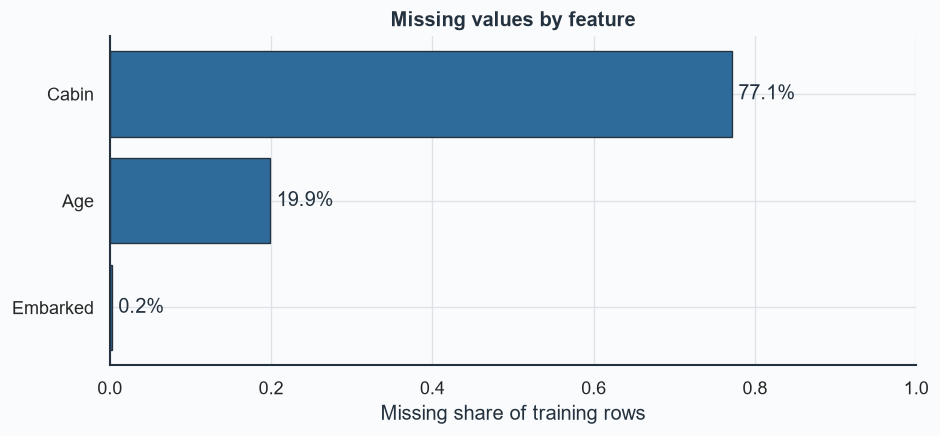

In [5]:
missing_plot = missing_table.query("missing_count > 0").sort_values("missing_rate")

fig, ax = plt.subplots(figsize=(8, 3.8))
bars = ax.barh(
    missing_plot.index,
    missing_plot["missing_rate"],
    color=PALETTE["blue"],
    edgecolor=PALETTE["ink"],
    linewidth=0.8,
)
ax.bar_label(bars, labels=[f"{v:.1%}" for v in missing_plot["missing_rate"]], padding=4)
ax.set(
    title="Missing values by feature",
    xlabel="Missing share of training rows",
    ylabel="",
    xlim=(0, max(1.0, missing_plot["missing_rate"].max() * 1.18)),
)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

**Interpretation / 読み方:** 欠損率が高い列を単純に削除するのではなく、「欠損そのものが情報か」を検討します。
`Cabin` は文字列を直接使わず、まず `CabinKnown`（記録の有無）に圧縮します。`Age` は学習 fold 内の中央値で補完します。

*Missingness can carry information. We turn Cabin availability into a binary feature and impute Age inside each training fold.*

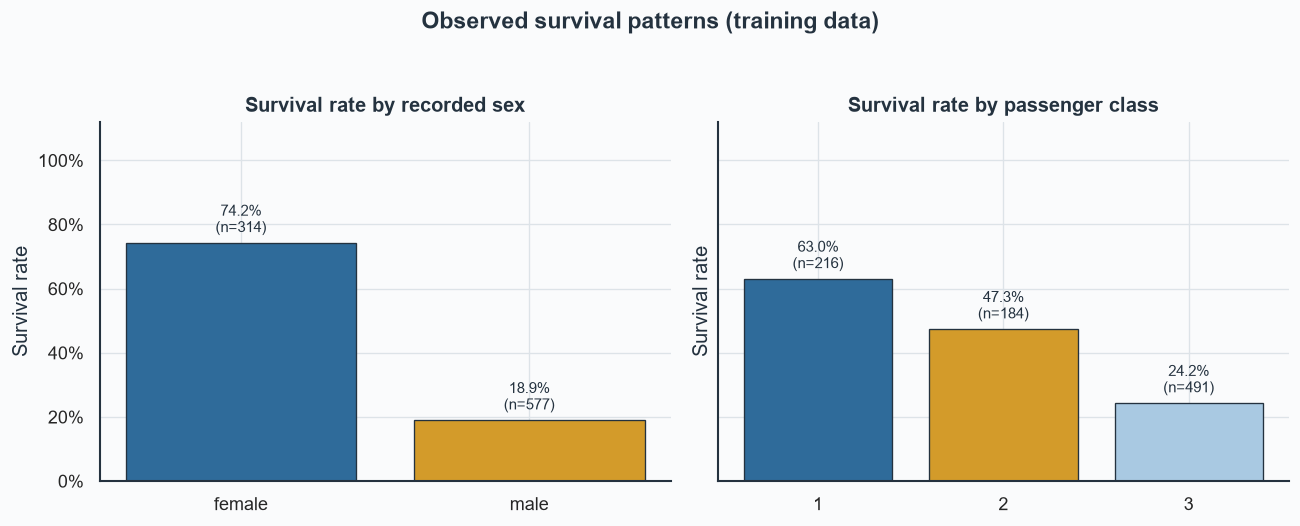

,Sex,passengers,survivors,survival_rate
0,female,314,233,74.2%
1,male,577,109,18.9%


,Pclass,passengers,survivors,survival_rate
0,1,216,136,63.0%
1,2,184,87,47.3%
2,3,491,119,24.2%


In [6]:
def rate_table(frame: pd.DataFrame, group_col: str) -> pd.DataFrame:
    result = (
        frame.groupby(group_col, dropna=False)["Survived"]
        .agg(passengers="size", survivors="sum", survival_rate="mean")
        .reset_index()
    )
    return result

sex_rates = rate_table(train, "Sex").sort_values("survival_rate", ascending=False)
class_rates = rate_table(train, "Pclass").sort_values("Pclass")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)

for ax, table, category, title in [
    (axes[0], sex_rates, "Sex", "Survival rate by recorded sex"),
    (axes[1], class_rates, "Pclass", "Survival rate by passenger class"),
]:
    bars = ax.bar(
        table[category].astype(str),
        table["survival_rate"],
        color=[PALETTE["blue"], PALETTE["gold"], PALETTE["blue_light"]][:len(table)],
        edgecolor=PALETTE["ink"],
        linewidth=0.8,
    )
    labels = [
        f"{rate:.1%}\n(n={count})"
        for rate, count in zip(table["survival_rate"], table["passengers"])
    ]
    ax.bar_label(bars, labels=labels, padding=4, fontsize=9)
    ax.set(title=title, xlabel="", ylabel="Survival rate", ylim=(0, 1.12))
    ax.yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
    sns.despine(ax=ax)

fig.suptitle("Observed survival patterns (training data)", y=1.04, fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

sex_rates_display = sex_rates.copy()
class_rates_display = class_rates.copy()
sex_rates_display["survival_rate"] = sex_rates_display["survival_rate"].map("{:.1%}".format)
class_rates_display["survival_rate"] = class_rates_display["survival_rate"].map("{:.1%}".format)
display(sex_rates_display)
display(class_rates_display)

**Interpretation / 読み方:** 棒の高さだけでなく `n=` を確認します。大きな率の差があっても、これは救命方針、客室位置、家族構成などが絡む観察結果です。
*Always read the denominator. The gaps are descriptive associations with many intertwined factors.*

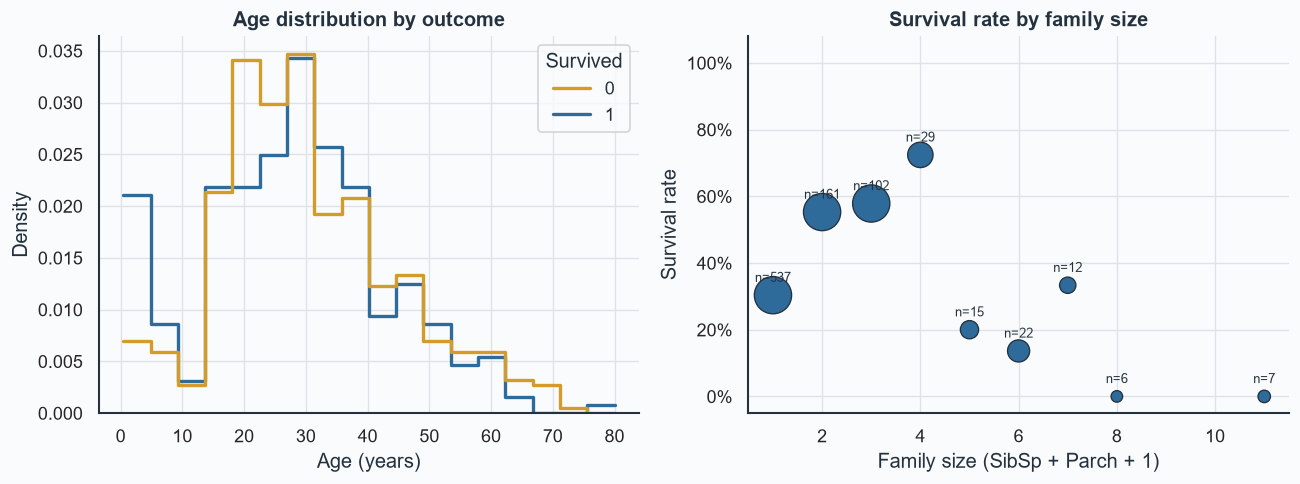

In [7]:
eda = train.copy()
eda["FamilySize"] = eda["SibSp"] + eda["Parch"] + 1
eda["IsAlone"] = np.where(eda["FamilySize"].eq(1), "Alone", "With family")

family_rates = (
    eda.groupby("FamilySize")["Survived"]
    .agg(passengers="size", survival_rate="mean")
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

sns.histplot(
    data=eda,
    x="Age",
    hue="Survived",
    bins=18,
    stat="density",
    common_norm=False,
    element="step",
    fill=False,
    palette={0: PALETTE["gold"], 1: PALETTE["blue"]},
    linewidth=2,
    ax=axes[0],
)
axes[0].set(title="Age distribution by outcome", xlabel="Age (years)", ylabel="Density")

axes[1].scatter(
    family_rates["FamilySize"],
    family_rates["survival_rate"],
    s=np.clip(family_rates["passengers"] * 8, 35, 500),
    color=PALETTE["blue"],
    edgecolor=PALETTE["ink"],
    linewidth=0.8,
)
for row in family_rates.itertuples():
    axes[1].annotate(
        f"n={row.passengers}",
        (row.FamilySize, row.survival_rate),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        fontsize=8,
    )
axes[1].set(
    title="Survival rate by family size",
    xlabel="Family size (SibSp + Parch + 1)",
    ylabel="Survival rate",
    ylim=(-0.05, 1.08),
)
axes[1].yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")

for ax in axes:
    sns.despine(ax=ax)
plt.tight_layout()
plt.show()

### Hypothesis / 仮説

家族人数と生存率の関係は非線形に見えます。しかし、可視化でパターンが見えたことと、未知データで精度が上がることは別です。

> **H1:** `FamilySize`, `IsAlone`, `Title`, `CabinKnown` add stable predictive signal.
> **H0:** The apparent pattern is redundant, unstable, or too sparse to improve generalization.

次節では、同じ Logistic Regression のまま特徴量だけを変える controlled ablation を行います。
*We change the feature representation while holding the model fixed.*

## 5. Modeling / モデル

### Feature engineering without target leakage / 目的変数を使わない特徴量設計

- `Title`: 氏名から敬称を抽出し、低頻度カテゴリを `Rare` に統合
- `FamilySize`: `SibSp + Parch + 1`
- `IsAlone`: `FamilySize == 1`
- `CabinKnown`: 客室番号が記録されているか

すべて `Survived` を参照せずに作成します。補完・標準化・one-hot は Pipeline 内で fold ごとに学習します。
*All learned preprocessing stays inside the cross-validation pipeline.*

In [8]:
COMMON_TITLES = {"Mr", "Miss", "Mrs", "Master"}

def add_features(frame: pd.DataFrame) -> pd.DataFrame:
    features = frame.copy()
    extracted_title = features["Name"].str.extract(r",\s*([^.]*)\.", expand=False).str.strip()
    features["Title"] = extracted_title.where(extracted_title.isin(COMMON_TITLES), "Rare")
    features["FamilySize"] = features["SibSp"] + features["Parch"] + 1
    features["IsAlone"] = features["FamilySize"].eq(1).astype(int)
    features["CabinKnown"] = features["Cabin"].notna().astype(int)
    return features

train_features = add_features(train)
test_features = add_features(test)

base_numeric = ["Pclass", "Age", "SibSp", "Parch", "Fare"]
base_categorical = ["Sex", "Embarked"]
family_numeric = base_numeric + ["FamilySize", "IsAlone"]
family_categorical = base_categorical
enhanced_numeric = family_numeric + ["CabinKnown"]
enhanced_categorical = base_categorical + ["Title"]

display(
    train_features[
        ["Name", "Title", "FamilySize", "IsAlone", "CabinKnown"]
    ].head(8)
)

,Name,Title,FamilySize,IsAlone,CabinKnown
0,"Braund, Mr. Owen Harris",Mr,2,0,0
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Mrs,2,0,1
2,"Heikkinen, Miss. Laina",Miss,1,1,0
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Mrs,2,0,1
4,"Allen, Mr. William Henry",Mr,1,1,0
5,"Moran, Mr. James",Mr,1,1,0
6,"McCarthy, Mr. Timothy J",Mr,1,1,1
7,"Palsson, Master. Gosta Leonard",Master,5,0,0


In [9]:
def make_preprocessor(numeric_features, categorical_features):
    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])
    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])
    return ColumnTransformer([
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features),
    ])


def make_pipeline(model, numeric_features, categorical_features):
    return Pipeline([
        ("preprocess", make_preprocessor(numeric_features, categorical_features)),
        ("model", model),
    ])


model_specs = {
    "Dummy baseline": (
        DummyClassifier(strategy="most_frequent"),
        base_numeric,
        base_categorical,
    ),
    "Logistic · base": (
        LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
        base_numeric,
        base_categorical,
    ),
    "Logistic · family": (
        LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
        family_numeric,
        family_categorical,
    ),
    "Logistic · enhanced": (
        LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
        enhanced_numeric,
        enhanced_categorical,
    ),
    "Random forest · enhanced": (
        RandomForestClassifier(
            n_estimators=300,
            min_samples_leaf=3,
            max_features="sqrt",
            random_state=RANDOM_STATE,
            n_jobs=1,
        ),
        enhanced_numeric,
        enhanced_categorical,
    ),
}

X_all = train_features.drop(columns="Survived")
y = train_features["Survived"].astype(int)

minority_count = int(y.value_counts().min())
n_splits = min(5, minority_count)
if n_splits < 2:
    raise ValueError("At least two observations are required in each target class.")

repeated_cv = RepeatedStratifiedKFold(
    n_splits=n_splits,
    n_repeats=3,
    random_state=RANDOM_STATE,
)

print(f"Repeated stratified CV: {n_splits} folds × 3 repeats = {n_splits * 3} validation scores/model")

Repeated stratified CV: 5 folds × 3 repeats = 15 validation scores/model


### Repeated cross-validation / 反復交差検証

平均値だけでなく分布を見ます。小規模データでは、1 回の分割が結論を大きく変えるためです。
*A score distribution is more informative than one lucky split.*

In [10]:
scoring = {"accuracy": "accuracy", "roc_auc": "roc_auc", "f1": "f1"}
cv_rows = []
fitted_pipelines = {}

for model_name, (estimator, numeric_features, categorical_features) in model_specs.items():
    pipeline = make_pipeline(estimator, numeric_features, categorical_features)
    fitted_pipelines[model_name] = pipeline
    scores = cross_validate(
        pipeline,
        X_all,
        y,
        cv=repeated_cv,
        scoring=scoring,
        n_jobs=1,
        return_train_score=False,
    )
    for fold_index in range(len(scores["test_accuracy"])):
        cv_rows.append({
            "model": model_name,
            "split": fold_index + 1,
            "accuracy": scores["test_accuracy"][fold_index],
            "roc_auc": scores["test_roc_auc"][fold_index],
            "f1": scores["test_f1"][fold_index],
        })

cv_results = pd.DataFrame(cv_rows)
cv_summary = (
    cv_results.groupby("model", sort=False)
    .agg(
        accuracy_mean=("accuracy", "mean"),
        accuracy_std=("accuracy", "std"),
        accuracy_min=("accuracy", "min"),
        accuracy_max=("accuracy", "max"),
        roc_auc_mean=("roc_auc", "mean"),
        f1_mean=("f1", "mean"),
    )
    .reset_index()
    .sort_values("accuracy_mean", ascending=False)
)

cv_summary_display = cv_summary.copy()
for metric_column in [
    "accuracy_mean", "accuracy_std", "accuracy_min",
    "accuracy_max", "roc_auc_mean", "f1_mean",
]:
    cv_summary_display[metric_column] = cv_summary_display[metric_column].map("{:.3f}".format)
display(cv_summary_display)

,model,accuracy_mean,accuracy_std,accuracy_min,accuracy_max,roc_auc_mean,f1_mean
4,Random forest · enhanced,0.831,0.017,0.798,0.854,0.876,0.767
3,Logistic · enhanced,0.824,0.017,0.798,0.855,0.871,0.766
2,Logistic · family,0.798,0.023,0.753,0.837,0.855,0.727
1,Logistic · base,0.792,0.024,0.747,0.826,0.852,0.721
0,Dummy baseline,0.616,0.002,0.612,0.618,0.500,0.000


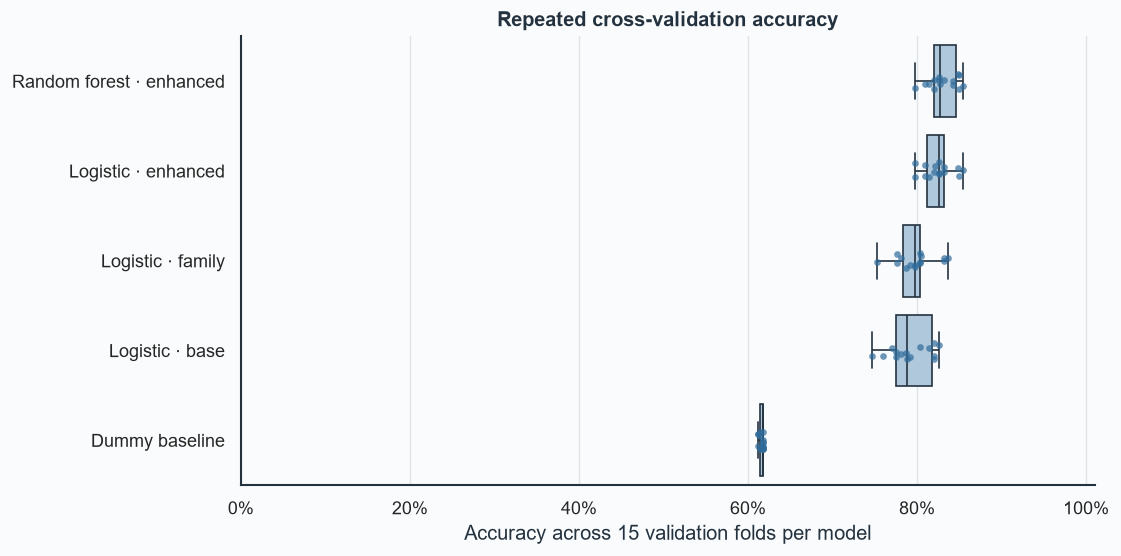

In [11]:
model_order = cv_summary["model"].tolist()

fig, ax = plt.subplots(figsize=(9.5, 4.8))
sns.boxplot(
    data=cv_results,
    x="accuracy",
    y="model",
    order=model_order,
    color=PALETTE["blue_light"],
    linecolor=PALETTE["ink"],
    whis=(0, 100),
    ax=ax,
)
sns.stripplot(
    data=cv_results,
    x="accuracy",
    y="model",
    order=model_order,
    color=PALETTE["blue"],
    size=4,
    alpha=0.7,
    ax=ax,
)
ax.set(
    title="Repeated cross-validation accuracy",
    xlabel=f"Accuracy across {n_splits * 3} validation folds per model",
    ylabel="",
    xlim=(0, 1.01),
)
ax.xaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

In [12]:
summary_lookup = cv_summary.set_index("model")
base_mean = summary_lookup.loc["Logistic · base", "accuracy_mean"]
family_mean = summary_lookup.loc["Logistic · family", "accuracy_mean"]
feature_delta = family_mean - base_mean

best_model_name = (
    cv_summary.loc[cv_summary["model"] != "Dummy baseline"]
    .sort_values(["accuracy_mean", "accuracy_std"], ascending=[False, True])
    .iloc[0]["model"]
)

direction = "improved" if feature_delta > 0 else "did not improve"
direction_ja = "改善した" if feature_delta > 0 else "改善しなかった"

display(Markdown(
    f"### Controlled ablation result / 特徴量比較の結果\n"
    f"- Logistic base mean accuracy: **{base_mean:.3f}**\n"
    f"- Logistic + family mean accuracy: **{family_mean:.3f}**\n"
    f"- Difference (family − base): **{feature_delta:+.3f}**\n\n"
    f"Under the same logistic model, family features **{direction}** mean CV accuracy.  \n"
    f"同じ Logistic Regression では、家族特徴量により平均 CV Accuracy は **{direction_ja}**。\n\n"
    f"Selected non-dummy model for the next diagnostic step: **{best_model_name}**"
))

### Controlled ablation result / 特徴量比較の結果
- Logistic base mean accuracy: **0.792**
- Logistic + family mean accuracy: **0.798**
- Difference (family − base): **+0.006**

Under the same logistic model, family features **improved** mean CV accuracy.  
同じ Logistic Regression では、家族特徴量により平均 CV Accuracy は **改善した**。

Selected non-dummy model for the next diagnostic step: **Random forest · enhanced**

### Why this comparison is useful / なぜこの比較が重要か

過去の試行では `FamilySize` 導入と木の深さ変更を同時に行い、Public Score が **0.77990 → 0.74162** に低下しました。
その結果だけでは「特徴量が悪い」のか「深さが悪い」のか分離できません。

| Tracked submission | Public score | Interpretation |
|---|---:|---|
| Depth-3 baseline | 0.77990 | Reference |
| Depth-5 + FamilySize replacement | 0.74162 | Failed experiment; two factors changed |

この Notebook では、まず同じモデルで特徴量だけを変えました。
*The leaderboard scores above are historical submission records, not recomputed CV results. The controlled ablation here isolates feature representation.*

## 6. Error Analysis / 誤分類分析

モデル選択と性能推定に同じ CV を使うと、選択後の数値は少し楽観的になります。ここでは最終性能の断言ではなく、**失敗パターンの診断**に OOF prediction を使います。
*OOF predictions below are diagnostic; nested CV would be needed for an unbiased post-selection estimate.*

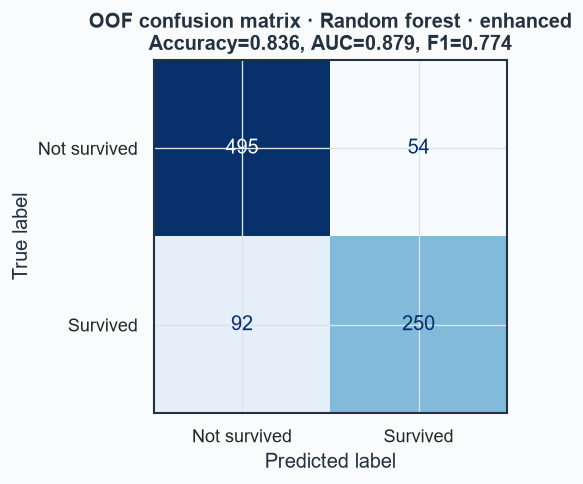

In [13]:
diagnostic_cv = StratifiedKFold(
    n_splits=n_splits,
    shuffle=True,
    random_state=RANDOM_STATE,
)
best_pipeline = clone(fitted_pipelines[best_model_name])

oof_pred = cross_val_predict(
    best_pipeline,
    X_all,
    y,
    cv=diagnostic_cv,
    method="predict",
    n_jobs=1,
)
oof_proba = cross_val_predict(
    best_pipeline,
    X_all,
    y,
    cv=diagnostic_cv,
    method="predict_proba",
    n_jobs=1,
)[:, 1]

oof_accuracy = accuracy_score(y, oof_pred)
oof_auc = roc_auc_score(y, oof_proba)
oof_f1 = f1_score(y, oof_pred)

fig, ax = plt.subplots(figsize=(5.2, 4.2))
ConfusionMatrixDisplay.from_predictions(
    y,
    oof_pred,
    display_labels=["Not survived", "Survived"],
    cmap="Blues",
    colorbar=False,
    ax=ax,
)
ax.set_title(f"OOF confusion matrix · {best_model_name}\nAccuracy={oof_accuracy:.3f}, AUC={oof_auc:.3f}, F1={oof_f1:.3f}")
plt.tight_layout()
plt.show()

,dimension,group,passengers,survivors,accuracy,survivor_recall
0,Sex,female,314,233,80.6%,92.7%
1,Sex,male,577,109,85.3%,31.2%
2,Pclass,1,216,136,80.1%,76.5%
3,Pclass,2,184,87,92.4%,90.8%
4,Pclass,3,491,119,81.9%,56.3%


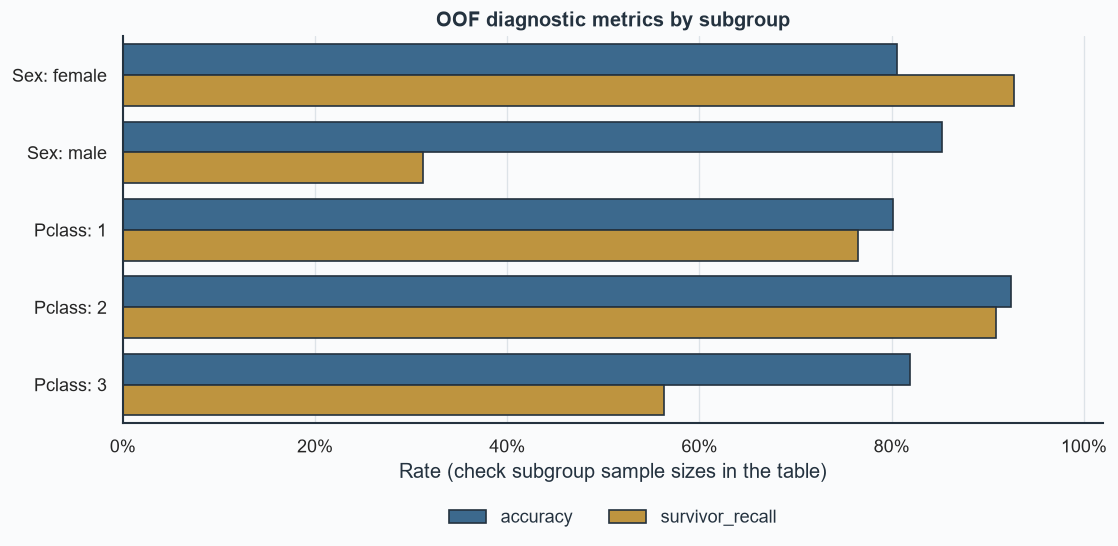

In [14]:
diagnostic = train_features[["PassengerId", "Sex", "Pclass", "Survived"]].copy()
diagnostic["Predicted"] = oof_pred
diagnostic["Correct"] = diagnostic["Survived"].eq(diagnostic["Predicted"])

subgroup_rows = []
for dimension in ["Sex", "Pclass"]:
    for group_value, group in diagnostic.groupby(dimension):
        actual_survivors = group["Survived"].eq(1)
        subgroup_rows.append({
            "dimension": dimension,
            "group": str(group_value),
            "passengers": len(group),
            "survivors": int(actual_survivors.sum()),
            "accuracy": accuracy_score(group["Survived"], group["Predicted"]),
            "survivor_recall": (
                recall_score(group["Survived"], group["Predicted"], pos_label=1)
                if actual_survivors.any() else np.nan
            ),
        })

subgroup_metrics = pd.DataFrame(subgroup_rows)
subgroup_display = subgroup_metrics.copy()
subgroup_display["accuracy"] = subgroup_display["accuracy"].map("{:.1%}".format)
subgroup_display["survivor_recall"] = subgroup_display["survivor_recall"].map(
    lambda value: "N/A" if pd.isna(value) else f"{value:.1%}"
)
display(subgroup_display)

plot_metrics = subgroup_metrics.melt(
    id_vars=["dimension", "group", "passengers", "survivors"],
    value_vars=["accuracy", "survivor_recall"],
    var_name="metric",
    value_name="value",
)
plot_metrics["label"] = plot_metrics["dimension"] + ": " + plot_metrics["group"]

fig, ax = plt.subplots(figsize=(9.5, 4.8))
sns.barplot(
    data=plot_metrics,
    x="value",
    y="label",
    hue="metric",
    palette=[PALETTE["blue"], PALETTE["gold"]],
    edgecolor=PALETTE["ink"],
    ax=ax,
)
ax.set(
    title="OOF diagnostic metrics by subgroup",
    xlabel="Rate (check subgroup sample sizes in the table)",
    ylabel="",
    xlim=(0, 1.02),
)
ax.xaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
ax.legend(
    title="",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.18),
    ncol=2,
    frameon=False,
)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

**Interpretation / 読み方:** `survivor_recall` は「実際に生存した人のうち、何割を生存と予測できたか」です。
全体 Accuracy が同じでも、特定グループの見逃し方は異なり得ます。小標本の率は不安定なので、必ず `survivors` 列と一緒に読みます。

*Subgroup diagnostics reveal failure modes, but small denominators make rates unstable. This is not a fairness certification.*

### Permutation importance / 置換重要度

別 holdout 上で 1 列ずつランダムに崩し、Accuracy の低下を測ります。負値は「有限標本の揺れ」や冗長性で起こり得ます。
*Permutation importance is model- and split-dependent; it is not causality.*

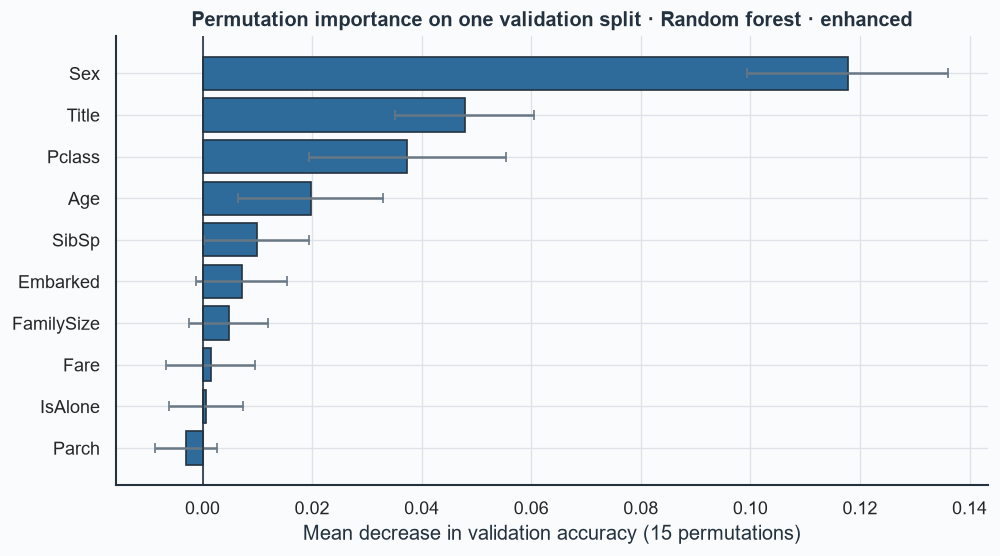

In [15]:
_, best_numeric, best_categorical = model_specs[best_model_name]
best_feature_columns = best_numeric + best_categorical
X_for_importance = X_all[best_feature_columns]

X_train, X_valid, y_train, y_valid = train_test_split(
    X_for_importance,
    y,
    test_size=0.25,
    stratify=y,
    random_state=RANDOM_STATE,
)
importance_pipeline = clone(fitted_pipelines[best_model_name])
importance_pipeline.fit(X_train, y_train)

importance = permutation_importance(
    importance_pipeline,
    X_valid,
    y_valid,
    scoring="accuracy",
    n_repeats=15,
    random_state=RANDOM_STATE,
    n_jobs=1,
)
importance_table = (
    pd.DataFrame({
        "feature": X_valid.columns,
        "importance_mean": importance.importances_mean,
        "importance_std": importance.importances_std,
    })
    .sort_values("importance_mean", ascending=False)
    .head(10)
    .sort_values("importance_mean")
)

fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.barh(
    importance_table["feature"],
    importance_table["importance_mean"],
    xerr=importance_table["importance_std"],
    color=PALETTE["blue"],
    edgecolor=PALETTE["ink"],
    ecolor=PALETTE["muted"],
    capsize=3,
)
ax.axvline(0, color=PALETTE["ink"], linewidth=1)
ax.set(
    title=f"Permutation importance on one validation split · {best_model_name}",
    xlabel="Mean decrease in validation accuracy (15 permutations)",
    ylabel="",
)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

## 7. Submission / 提出

最終モデルを全学習データで fit し、`PassengerId` と 0/1 予測だけを保存します。
*The competition test labels remain untouched.*

In [16]:
final_pipeline = clone(fitted_pipelines[best_model_name])
final_pipeline.fit(X_all, y)
test_pred = final_pipeline.predict(test_features.drop(columns="Survived", errors="ignore")).astype(int)

submission = pd.DataFrame({
    "PassengerId": test["PassengerId"],
    "Survived": test_pred,
})

assert len(submission) == len(test), "Submission row count mismatch"
assert submission["PassengerId"].equals(test["PassengerId"]), "PassengerId order changed"
assert submission["PassengerId"].is_unique, "Duplicate PassengerId"
assert set(submission["Survived"].unique()).issubset({0, 1}), "Predictions must be 0/1"
assert submission.isna().sum().sum() == 0, "Submission contains missing values"

submission_filename = "submission.csv" if is_official_shape else "submission_smoke.csv"
submission_path = OUTPUT_DIR / submission_filename
submission.to_csv(submission_path, index=False)

display(submission.head())
display(Markdown(
    f"✅ Saved / 保存先: `{submission_path}`  \n"
    f"Rows / 行数: **{len(submission)}** · Predicted survival rate / 予測生存率: **{submission['Survived'].mean():.1%}**"
))

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1


✅ Saved / 保存先: `submissions\submission.csv`  
Rows / 行数: **418** · Predicted survival rate / 予測生存率: **37.6%**

## 8. Takeaways / まとめ

このセルは実行結果から自動生成します。Notebook を fork して特徴量やモデルを変えても、文章と数値がずれにくい設計です。
*The summary is generated from executed results so prose and numbers stay aligned.*

In [17]:
winner = cv_summary.iloc[0]
spread = winner["accuracy_max"] - winner["accuracy_min"]
ablation_message_ja = (
    "家族特徴量は同一 Logistic モデルで平均精度を改善しました。"
    if feature_delta > 0
    else "家族特徴量は同一 Logistic モデルで平均精度を改善しませんでした。"
)
ablation_message_en = (
    "Family features improved mean accuracy under the same logistic model."
    if feature_delta > 0
    else "Family features did not improve mean accuracy under the same logistic model."
)

official_note = (
    "公式 Titanic データで実行済みです。"
    if is_official_shape
    else "現在はスモークデータです。投稿前に公式 Titanic データで再実行してください。"
)
official_note_en = (
    "Executed on the official Titanic data."
    if is_official_shape
    else "Currently executed on smoke data; rerun on the official Titanic data before publishing."
)

display(Markdown(
    f"### 日本語\n"
    f"1. 反復 CV の最高平均 Accuracy は **{winner['accuracy_mean']:.3f}** "
    f"（**{winner['model']}**）でした。\n"
    f"2. 最高モデルでも split 間の最小–最大幅は **{spread:.3f}**。単一 split の結論は不安定です。\n"
    f"3. Base → Family Logistic の差は **{feature_delta:+.3f}**。{ablation_message_ja}\n"
    f"4. OOF 診断は Accuracy **{oof_accuracy:.3f}**, ROC AUC **{oof_auc:.3f}**, F1 **{oof_f1:.3f}**。\n"
    f"5. {official_note}\n\n"
    f"### English\n"
    f"1. Best repeated-CV mean accuracy: **{winner['accuracy_mean']:.3f}** "
    f"(**{winner['model']}**).\n"
    f"2. Its min–max split spread is **{spread:.3f}**, so one split is not enough.\n"
    f"3. Base → family logistic delta: **{feature_delta:+.3f}**. {ablation_message_en}\n"
    f"4. OOF diagnostic: accuracy **{oof_accuracy:.3f}**, ROC AUC **{oof_auc:.3f}**, F1 **{oof_f1:.3f}**.\n"
    f"5. {official_note_en}"
))

### 日本語
1. 反復 CV の最高平均 Accuracy は **0.831** （**Random forest · enhanced**）でした。
2. 最高モデルでも split 間の最小–最大幅は **0.056**。単一 split の結論は不安定です。
3. Base → Family Logistic の差は **+0.006**。家族特徴量は同一 Logistic モデルで平均精度を改善しました。
4. OOF 診断は Accuracy **0.836**, ROC AUC **0.879**, F1 **0.774**。
5. 公式 Titanic データで実行済みです。

### English
1. Best repeated-CV mean accuracy: **0.831** (**Random forest · enhanced**).
2. Its min–max split spread is **0.056**, so one split is not enough.
3. Base → family logistic delta: **+0.006**. Family features improved mean accuracy under the same logistic model.
4. OOF diagnostic: accuracy **0.836**, ROC AUC **0.879**, F1 **0.774**.
5. Executed on the official Titanic data.

### Limitations / 限界

- CV は leaderboard の完全な代替ではありません / CV is not the public leaderboard.
- モデル選択後の OOF 指標は診断用です / Post-selection OOF metrics are diagnostic.
- サブグループ率は小標本で不安定です / Small subgroup rates are unstable.
- 置換重要度は因果効果ではありません / Importance is not causality.
- Titanic は歴史的・倫理的にセンシティブな実データです / Treat the historical human data respectfully.

### Next experiments / 次の実験

1. `Title` だけ、`FamilySize` だけを 1 変更ずつ ablation。
2. Nested CV でモデル選択バイアスを分離。
3. Calibration curve と threshold sensitivity を追加。
4. 同一 CV split を固定し、実験表に平均・標準偏差・差分を記録。

---

If this notebook helped, please **upvote and comment with one experiment you would run next**.
役に立ったら、**次に試したい実験をコメント**してください。